In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/raw/Fraud_Data.csv")

df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
df.shape

(151112, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [5]:
df.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


The dataset contains customer transaction information including demographic variables, purchase behavior, device identifiers, and fraud labels.

In [6]:
df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

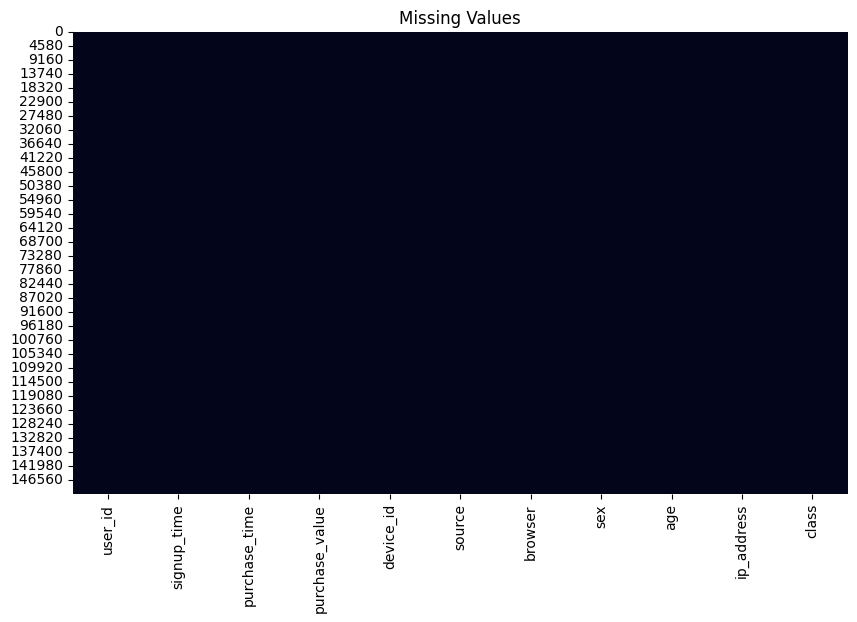

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

In [8]:
df.duplicated().sum()

np.int64(0)

Duplicate records were checked and removed where necessary to avoid bias during model training.

In [9]:
df["class"].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [10]:
df["class"].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

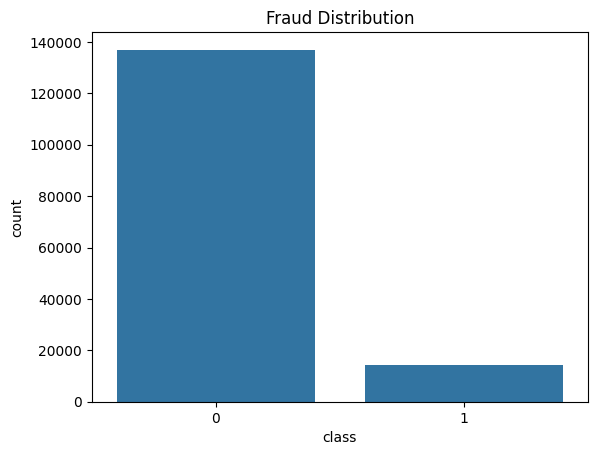

In [11]:
sns.countplot(
    x="class",
    data=df
)

plt.title("Fraud Distribution")
plt.show()

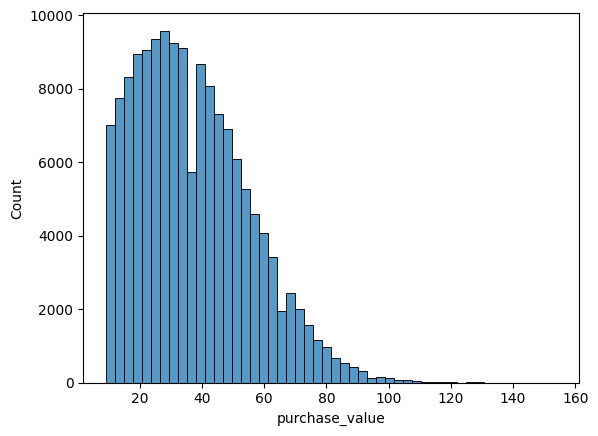

In [12]:
sns.histplot(
    df["purchase_value"],
    bins=50
)

plt.show()

Most transactions involve relatively small purchase amounts, while a few transactions contain exceptionally large values.

Age Distribution

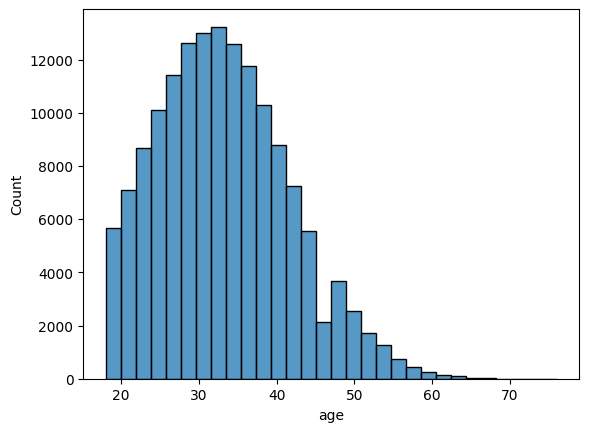

In [13]:
sns.histplot(
    df["age"],
    bins=30
)

plt.show()

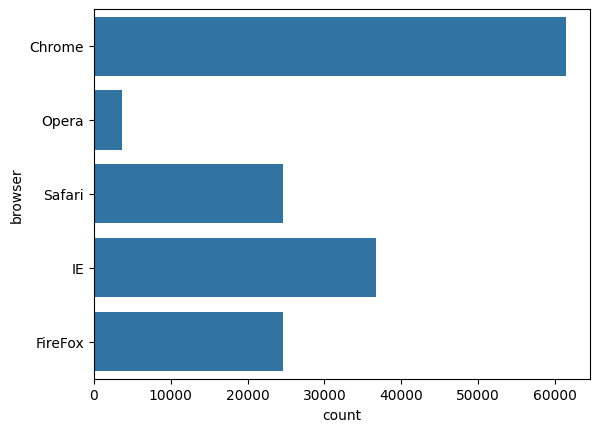

In [14]:
sns.countplot(
    y="browser",
    data=df
)

plt.show()

Chrome and IE account for the majority of transactions.

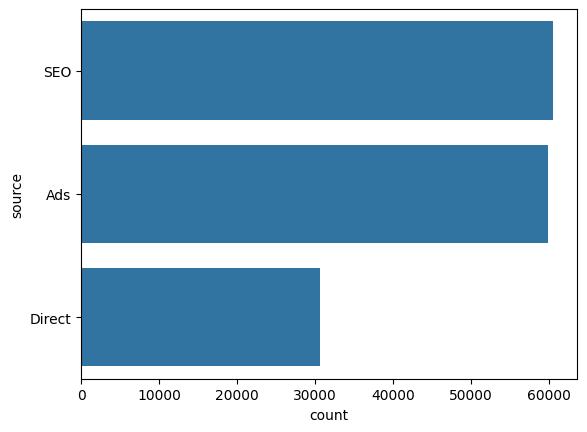

In [15]:
sns.countplot(
    y="source",
    data=df
)

plt.show()

The source variable may be useful for fraud detection because different acquisition channels could exhibit different fraud patterns. Further analysis should compare fraud rates across SEO, Ads, and Direct traffic to determine whether certain channels are associated with higher fraudulent activity.

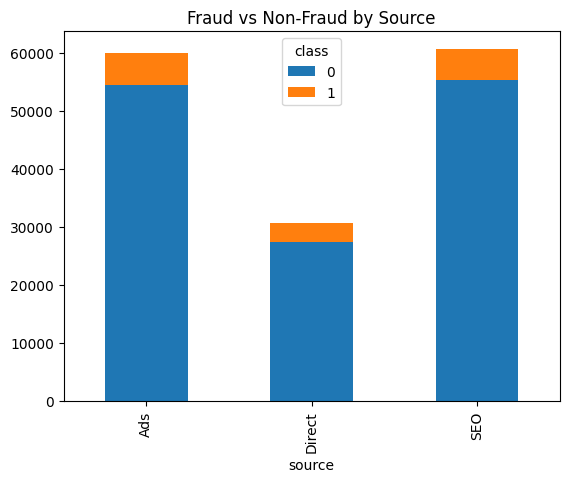

In [18]:
fraud_source = pd.crosstab(df["source"], df["class"])

fraud_source.plot(kind="bar", stacked=True)
plt.title("Fraud vs Non-Fraud by Source")
plt.show()

Across all traffic sources, non-fraudulent transactions (class 0) significantly outnumber fraudulent transactions (class 1), confirming the presence of a strong class imbalance in the dataset.

SEO and Ads generate the largest number of transactions overall, while Direct generates substantially fewer transactions.

In [16]:
ip_df = pd.read_csv(
    "../data/raw/IpAddress_to_Country.csv"
)

In [17]:
df["ip_address"] = df["ip_address"].astype(int)

apping IP addresses to countries enables geographic fraud analysis and may reveal regions with elevated fraud risk.

<Axes: xlabel='purchase_value', ylabel='Count'>

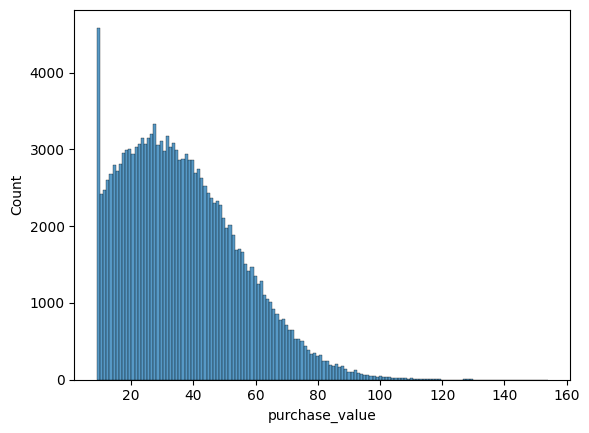

In [19]:
sns.histplot(df["purchase_value"])

Most customers make purchases of relatively low monetary value, while high-value transactions are uncommon. The purchase value distribution is positively skewed, indicating that a small number of transactions account for disproportionately large purchase amounts. Since unusually large purchases may be indicative of fraudulent behavior, purchase value is likely to be an important predictor in the fraud detection model.